In [ ]:
%pip install 

In [1]:
import re
import nltk
import pickle 
import pyLDAvis
import gensim
import pandas as pd
import numpy as np
from io import BytesIO
from zipfile import ZipFile
import urllib.request 
import pyLDAvis.gensim_models
from wordcloud import WordCloud
from gensim.utils import simple_preprocess
from nltk.corpus import stopwords
import gensim.corpora as corpora
from pprint import pprint
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import NMF, LatentDirichletAllocation

/Users/sooreoluwa/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
nltk.download('stopwords')
nltk.download('omw-1.4')
nltk.download('wordnet')

wn = nltk.WordNetLemmatizer()

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/sooreoluwa/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/sooreoluwa/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/sooreoluwa/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [3]:
url = urllib.request.urlopen("https://github.com/seigdev/resources/raw/main/nysk.xml.zip")

with ZipFile(BytesIO(url.read())) as my_zip_file:
    temp = my_zip_file.open('nysk.xml')

articles_df = pd.read_xml(temp, parser='etree')

# descrivbe the data
articles_df.describe(include='all')

,docid,source,url,title,summary,text,date
count,10421.000000,10421,10421,10421,10421,10421,10421
unique,NaN,1867,10421,7226,8507,9748,10368
top,NaN,www.reuters.com,http://www.fin24.com/Markets/Equities/Global-s...,Ex-IMF chief gets $1M bail in NYC sex assault ...,) (Reuters) © Copyright 2011 Thomson Reuters R...,"DOMINIQUE STRAUSS-KAHN, in a New York prison o...",2011-05-19 15:45:33
freq,NaN,189,1,51,113,20,2
mean,5210.000000,NaN,NaN,NaN,NaN,NaN,NaN
std,3008.427912,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
25%,2605.000000,NaN,NaN,NaN,NaN,NaN,NaN
50%,5210.000000,NaN,NaN,NaN,NaN,NaN,NaN
75%,7815.000000,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# remove columns that does not relate to the task 
articles_df = articles_df.drop(columns=['docid','source', 'url', 'summary', 'date'], axis=1)

articles_df.shape

(10421, 2)

In [5]:
# Remove punctuation
articles_df['cleaned_text'] = articles_df['text'].map(lambda x: re.sub('[,\.!?]', '', x))

# Convert the titles to lowercase
articles_df['cleaned_text'] = articles_df['cleaned_text'].map(lambda x: x.lower())

<>:2: DeprecationWarning: invalid escape sequence \.
<>:2: DeprecationWarning: invalid escape sequence \.
/var/folders/zn/6wprcrg968v6zv05_s_8vf180000gn/T/ipykernel_18613/2139573192.py:2: DeprecationWarning: invalid escape sequence \.
  articles_df['cleaned_text'] = articles_df['text'].map(lambda x: re.sub('[,\.!?]', '', x))


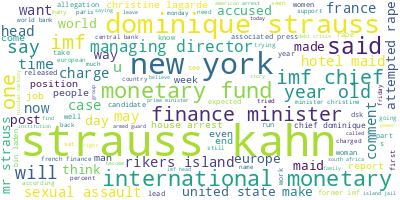

In [6]:
# Join the different processed titles together.
long_string = ','.join(list(articles_df['cleaned_text'].values))

# Create a WordCloud object
wordcloud = WordCloud(background_color="white", max_words=2000, contour_width=3, contour_color='steelblue')

# Generate a word cloud
wordcloud.generate(long_string)

# Visualize the word cloud
wordcloud.to_image()

In [7]:
# stop_words = stopwords.words('english')

# def sent_to_words(sentences):
#     for sentence in sentences:
#         # deacc=True removes punctuations
#         yield(gensim.utils.simple_preprocess(str(sentence), deacc=True))

# def remove_stopwords(texts):
#     return [[word for word in simple_preprocess(str(doc)) 
#              if word not in stop_words] for doc in texts]


# data = articles_df.cleaned_text.values.tolist()
# data_words = list(sent_to_words(data))

# # remove stop words
# data_words = remove_stopwords(data_words)

# print(data_words[:1][0][:30])

In [8]:
# Remove stopwords
stopwords = nltk.corpus.stopwords.words('english')
stopwords.extend(['mr', 'said','imf','using','say'])
print(f'There are {len(stopwords)} default stopwords. They are {stopwords}')

There are 203 default stopwords. They are ['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own',

In [9]:
# Remove stopwords
articles_df['text_without_stopwords'] = articles_df['text'].apply(lambda x: ' '.join([w for w in x.split() if w.lower() not in stopwords]))
# Lemmatization
articles_df['text_lemmatized'] = articles_df['text_without_stopwords'].apply(lambda x: ' '.join([wn.lemmatize(w) for w in x.split() if w not in stopwords]))
# Take a look at the data
articles_df.head()

,title,text,cleaned_text,text_without_stopwords,text_lemmatized
0,Dominique Strauss-Kahn Sex-Crime Case: Accuser...,The New York Post has learned that the woman a...,the new york post has learned that the woman a...,New York Post learned woman accusing boss Domi...,New York Post learned woman accusing bos Domin...
1,Strauss-Kahn’s NY apartment plan falls apart,Strauss-Kahn’s NY apartment plan falls apart A...,strauss-kahn’s ny apartment plan falls apart a...,Strauss-Kahn’s NY apartment plan falls apart A...,Strauss-Kahn’s NY apartment plan fall apart AF...
2,Why is France Falling for <em>Strauss-Kahn</em...,"According to a worrying CSA poll, it seems tha...",according to a worrying csa poll it seems that...,"According worrying CSA poll, seems 57% French ...","According worrying CSA poll, seems 57% French ..."
3,Traces of Strauss-Kahn's DNA found on alleged ...,Traces of Strauss-Kahn's DNA found on alleged ...,traces of strauss-kahn's dna found on alleged ...,Traces Strauss-Kahn's DNA found alleged victim...,Traces Strauss-Kahn's DNA found alleged victim...
4,Dominique Strauss-Kahn Resigns as IMF Chief,"Sajwert houseparty, usually I try not to answe...",sajwert houseparty usually i try not to answer...,"Sajwert houseparty, usually try answer people ...","Sajwert houseparty, usually try answer people ..."


In [10]:
# # for LDA, we need to convert the text into a bag of words

# # create Dictionary
# id2word = corpora.Dictionary(data_words)

# # create Corpus
# texts = data_words

# # term Document Frequency
# corpus = [id2word.doc2bow(text) for text in texts]

# # view
# print(corpus[:1][0][:30])

parameters selection

In [11]:
n_samples = 2000
n_features = 500
n_components = 10
n_top_words = 15
batch_size = 128
init = "nndsvda"

In [12]:
def plot_top_words(model, feature_names, n_top_words, title):
    fig, axes = plt.subplots(2, 5, figsize=(30, 15), sharex=True)
    axes = axes.flatten()
    for topic_idx, topic in enumerate(model.components_):
        top_features_ind = topic.argsort()[: -n_top_words - 1 : -1]
        top_features = [feature_names[i] for i in top_features_ind]
        weights = topic[top_features_ind]

        ax = axes[topic_idx]
        ax.barh(top_features, weights, height=0.7)
        ax.set_title(f"Topic {topic_idx +1}", fontdict={"fontsize": 30})
        ax.invert_yaxis()
        ax.tick_params(axis="both", which="major", labelsize=20)
        for i in "top right left".split():
            ax.spines[i].set_visible(False)
        fig.suptitle(title, fontsize=40)

    plt.subplots_adjust(top=0.90, bottom=0.05, wspace=0.90, hspace=0.3)
    plt.show()

In [13]:
print("Extracting tf features for LDA...")
tf_vectorizer = CountVectorizer(
    max_df=0.95, min_df=2, max_features=n_features, stop_words="english"
)
tf = tf_vectorizer.fit_transform(articles_df['text_lemmatized'])
print("Extracted tf features for LDA...")

Extracting tf features for LDA...
Extracted tf features for LDA...


In [14]:
print("Extracting tf-idf features for NMF...")
tfidf_vectorizer = TfidfVectorizer(
    max_df=0.95, min_df=2, max_features=n_features, stop_words="english"
)
tfidf = tfidf_vectorizer.fit_transform(articles_df['text_lemmatized'])
print("Extracted tf-idf features for NMF...")

Extracting tf-idf features for NMF...
Extracted tf-idf features for NMF...


#### Model Training

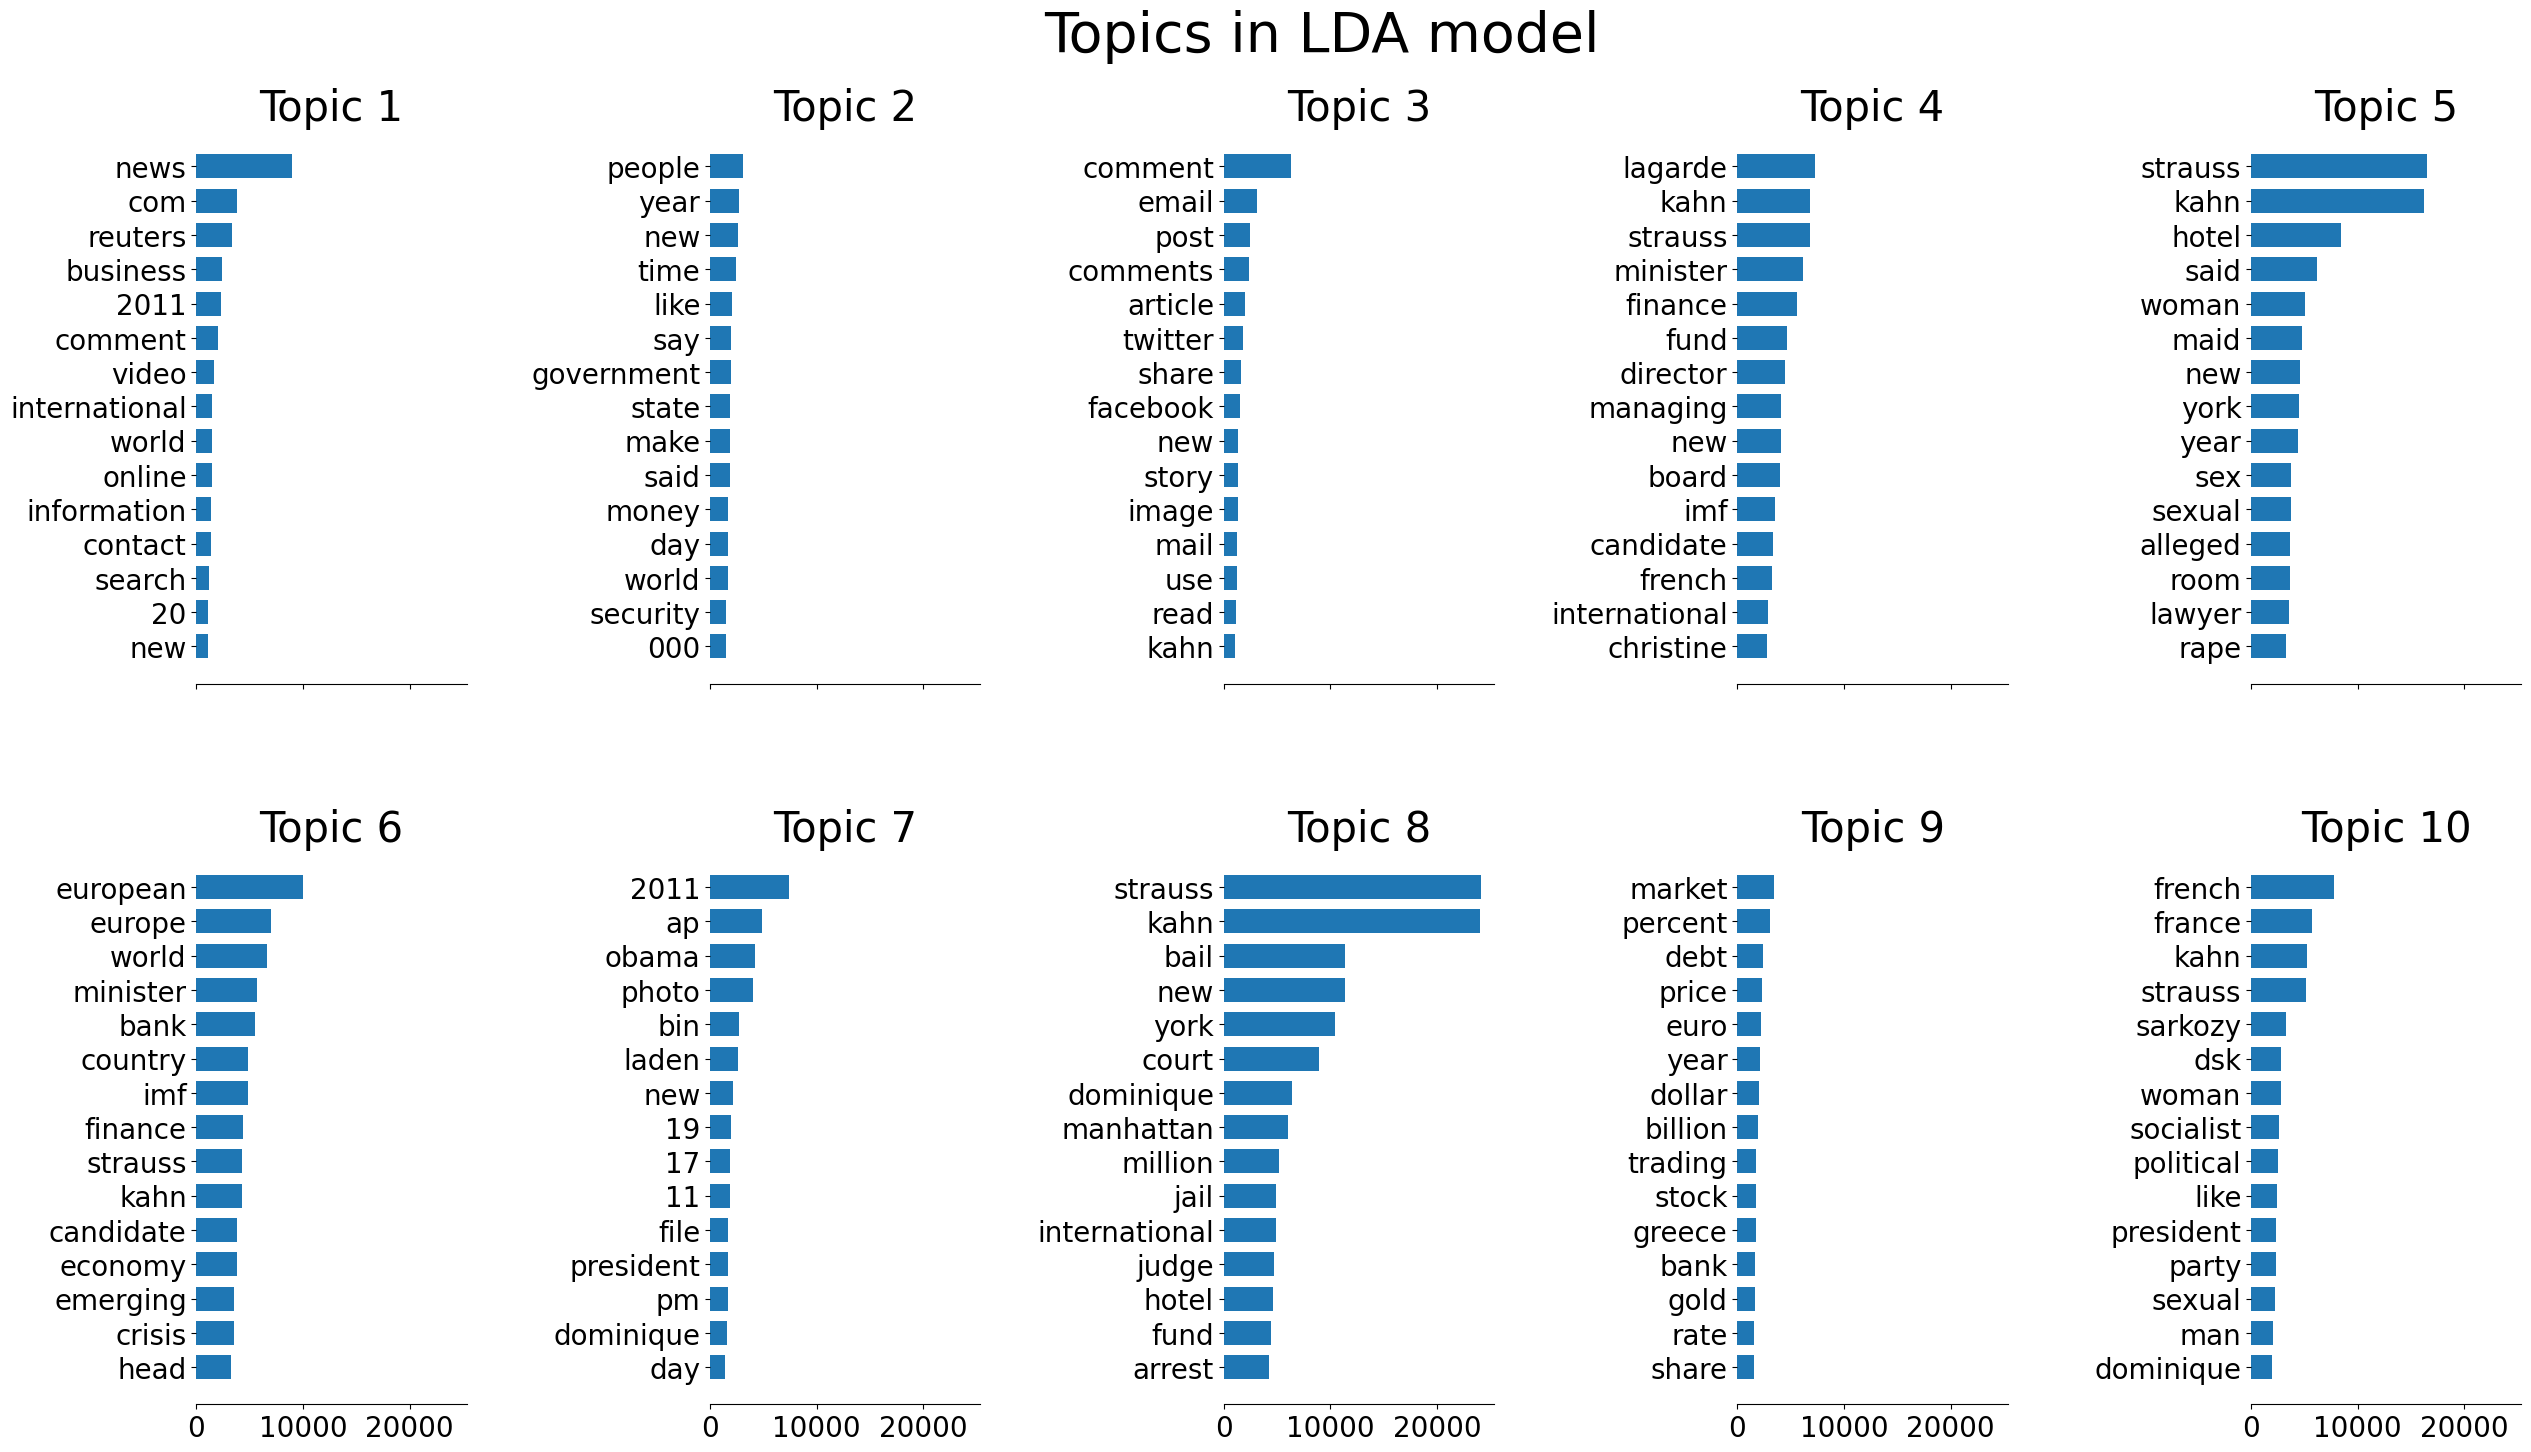

In [15]:
lda = LatentDirichletAllocation(
    n_components=n_components,
    max_iter=5,
    learning_method="online",
    learning_offset=50.0,
    random_state=0,
)
lda.fit(tf)
tf_feature_names = tf_vectorizer.get_feature_names_out()
plot_top_words(lda, tf_feature_names, n_top_words, "Topics in LDA model")

Fitting the NMF model (Frobenius norm) with tf-idf features, n_samples=2000 and n_features=500...


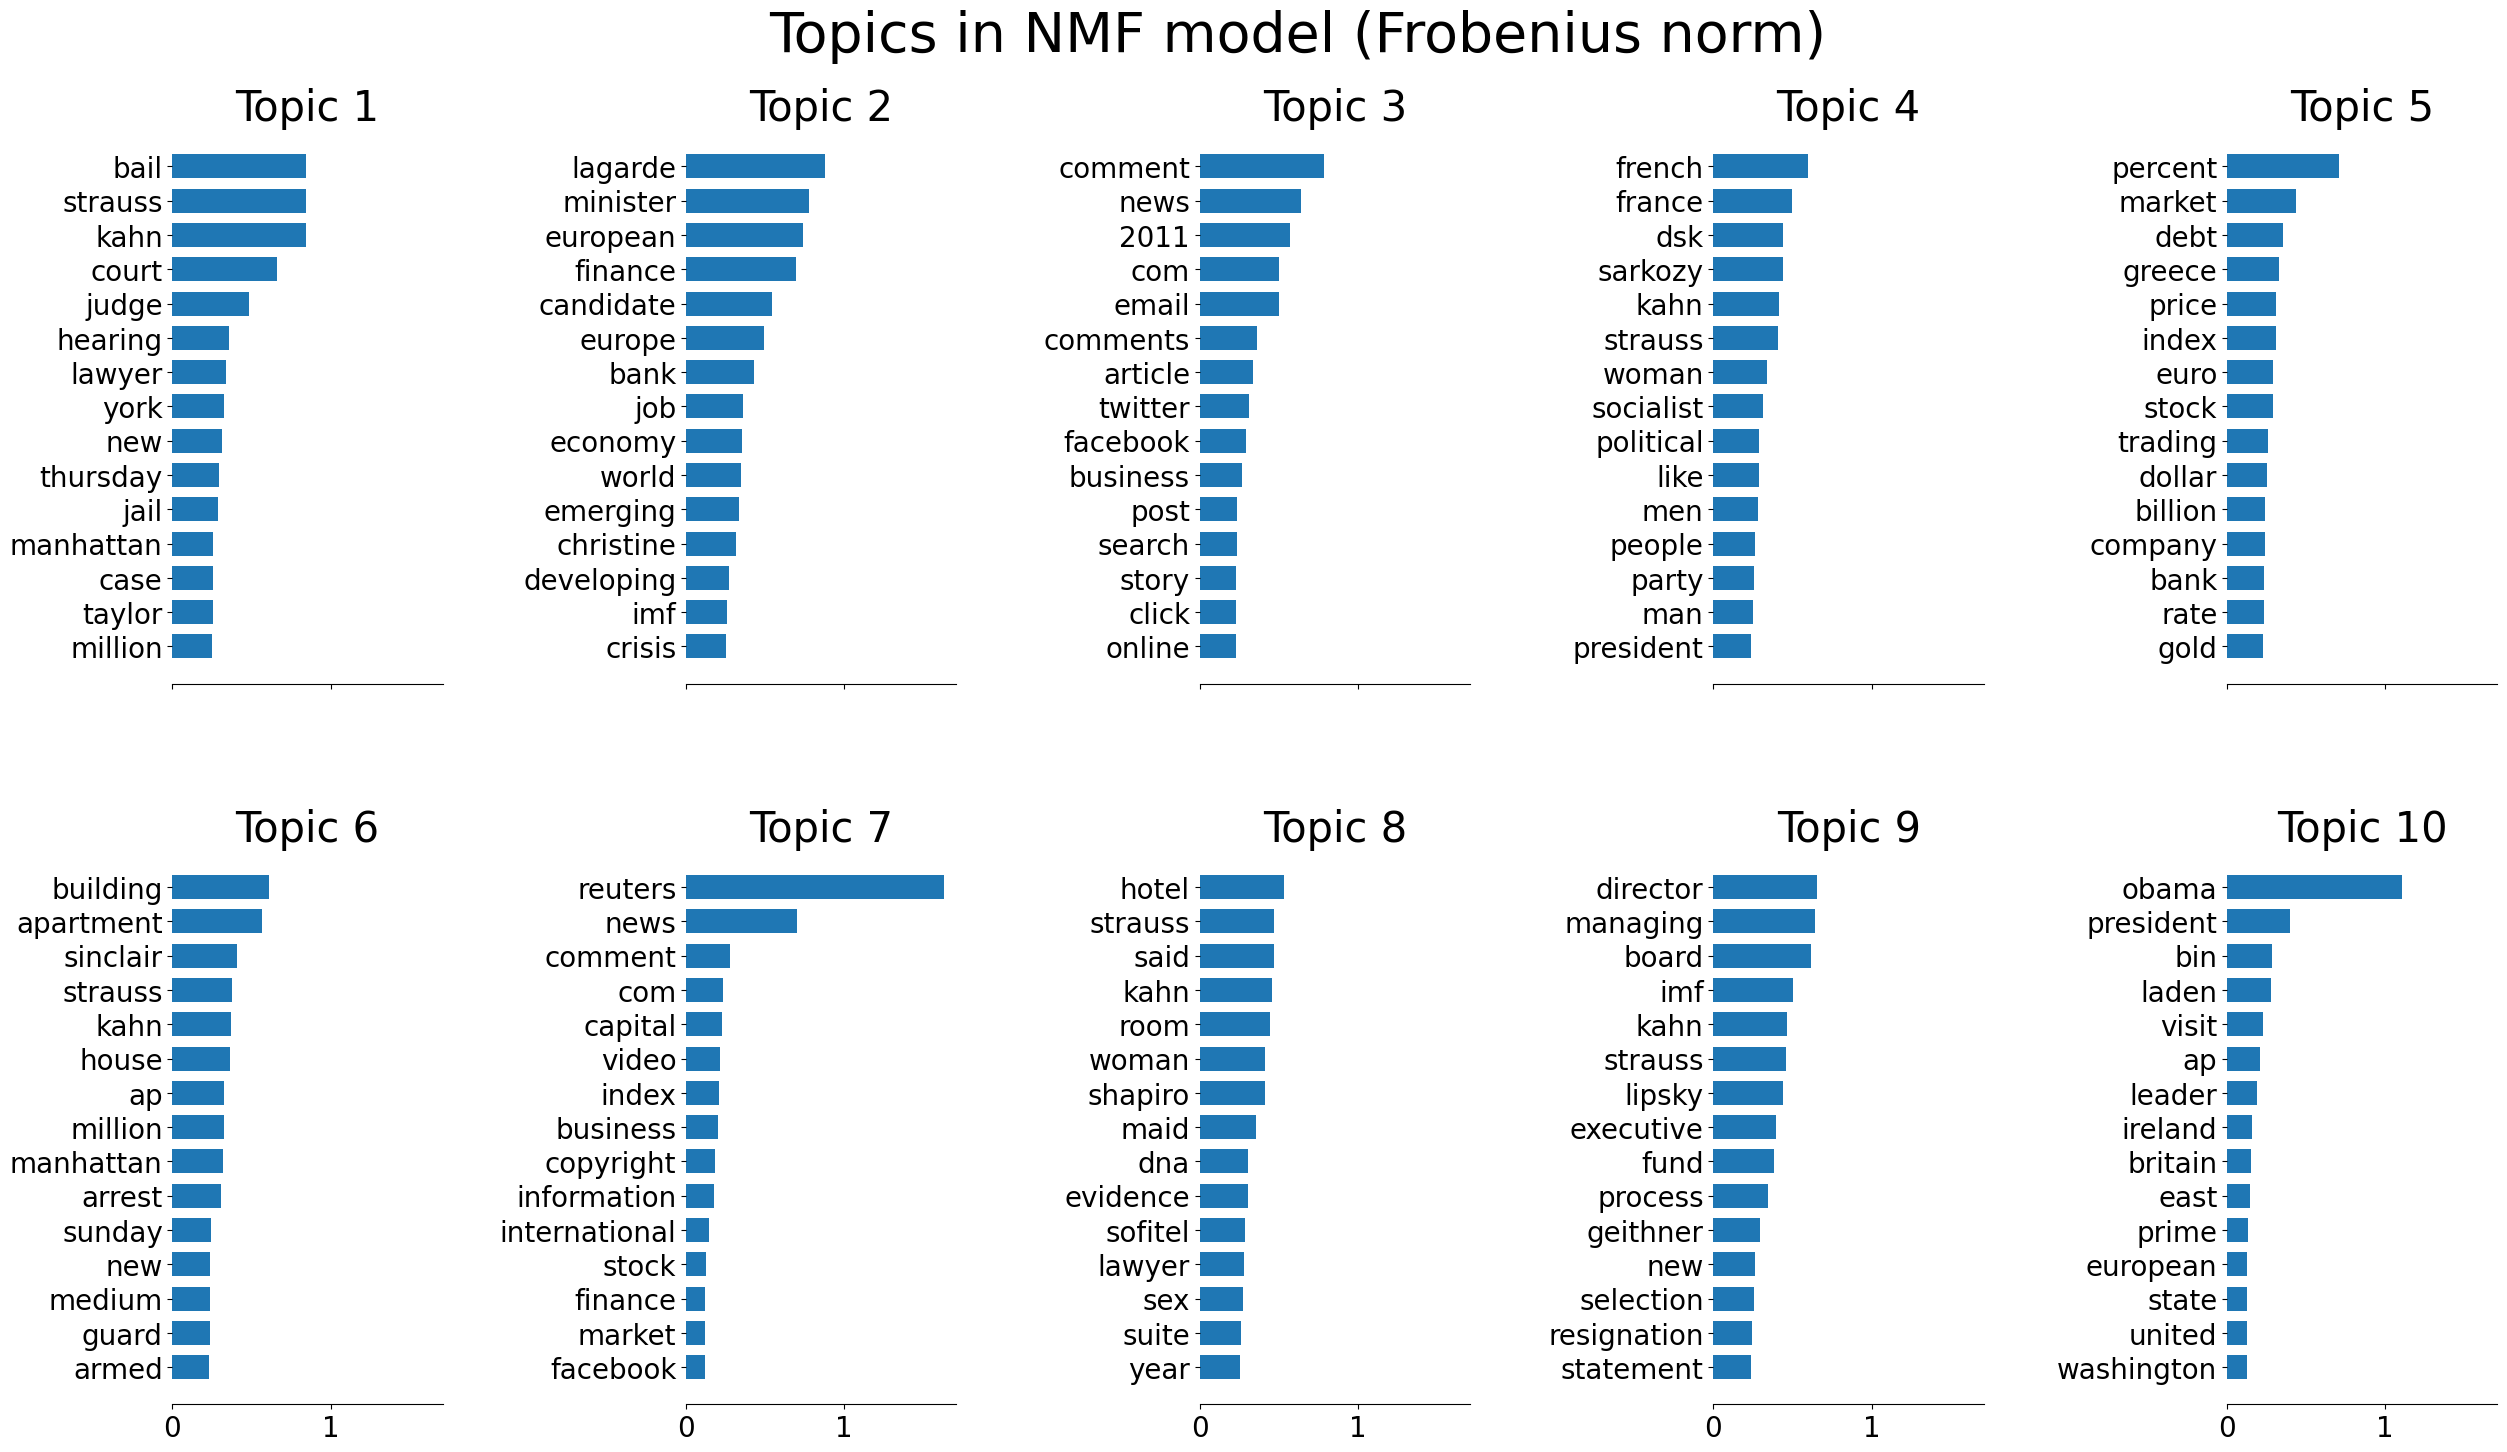

In [16]:

print(
    "Fitting the NMF model (Frobenius norm) with tf-idf features, "
    "n_samples=%d and n_features=%d..." % (n_samples, n_features)
)

nmf = NMF(
    n_components=n_components,
    random_state=1,
    init=init,
    beta_loss="frobenius",
    alpha_W=0.00005,
    alpha_H=0.00005,
    l1_ratio=1,
).fit(tfidf)
tfidf_feature_names = tfidf_vectorizer.get_feature_names_out()
plot_top_words(
    nmf, tfidf_feature_names, n_top_words, "Topics in NMF model (Frobenius norm)"
)



 Fitting the NMF model (generalized Kullback-Leibler divergence) with tf-idf features, n_samples=2000 and n_features=500...


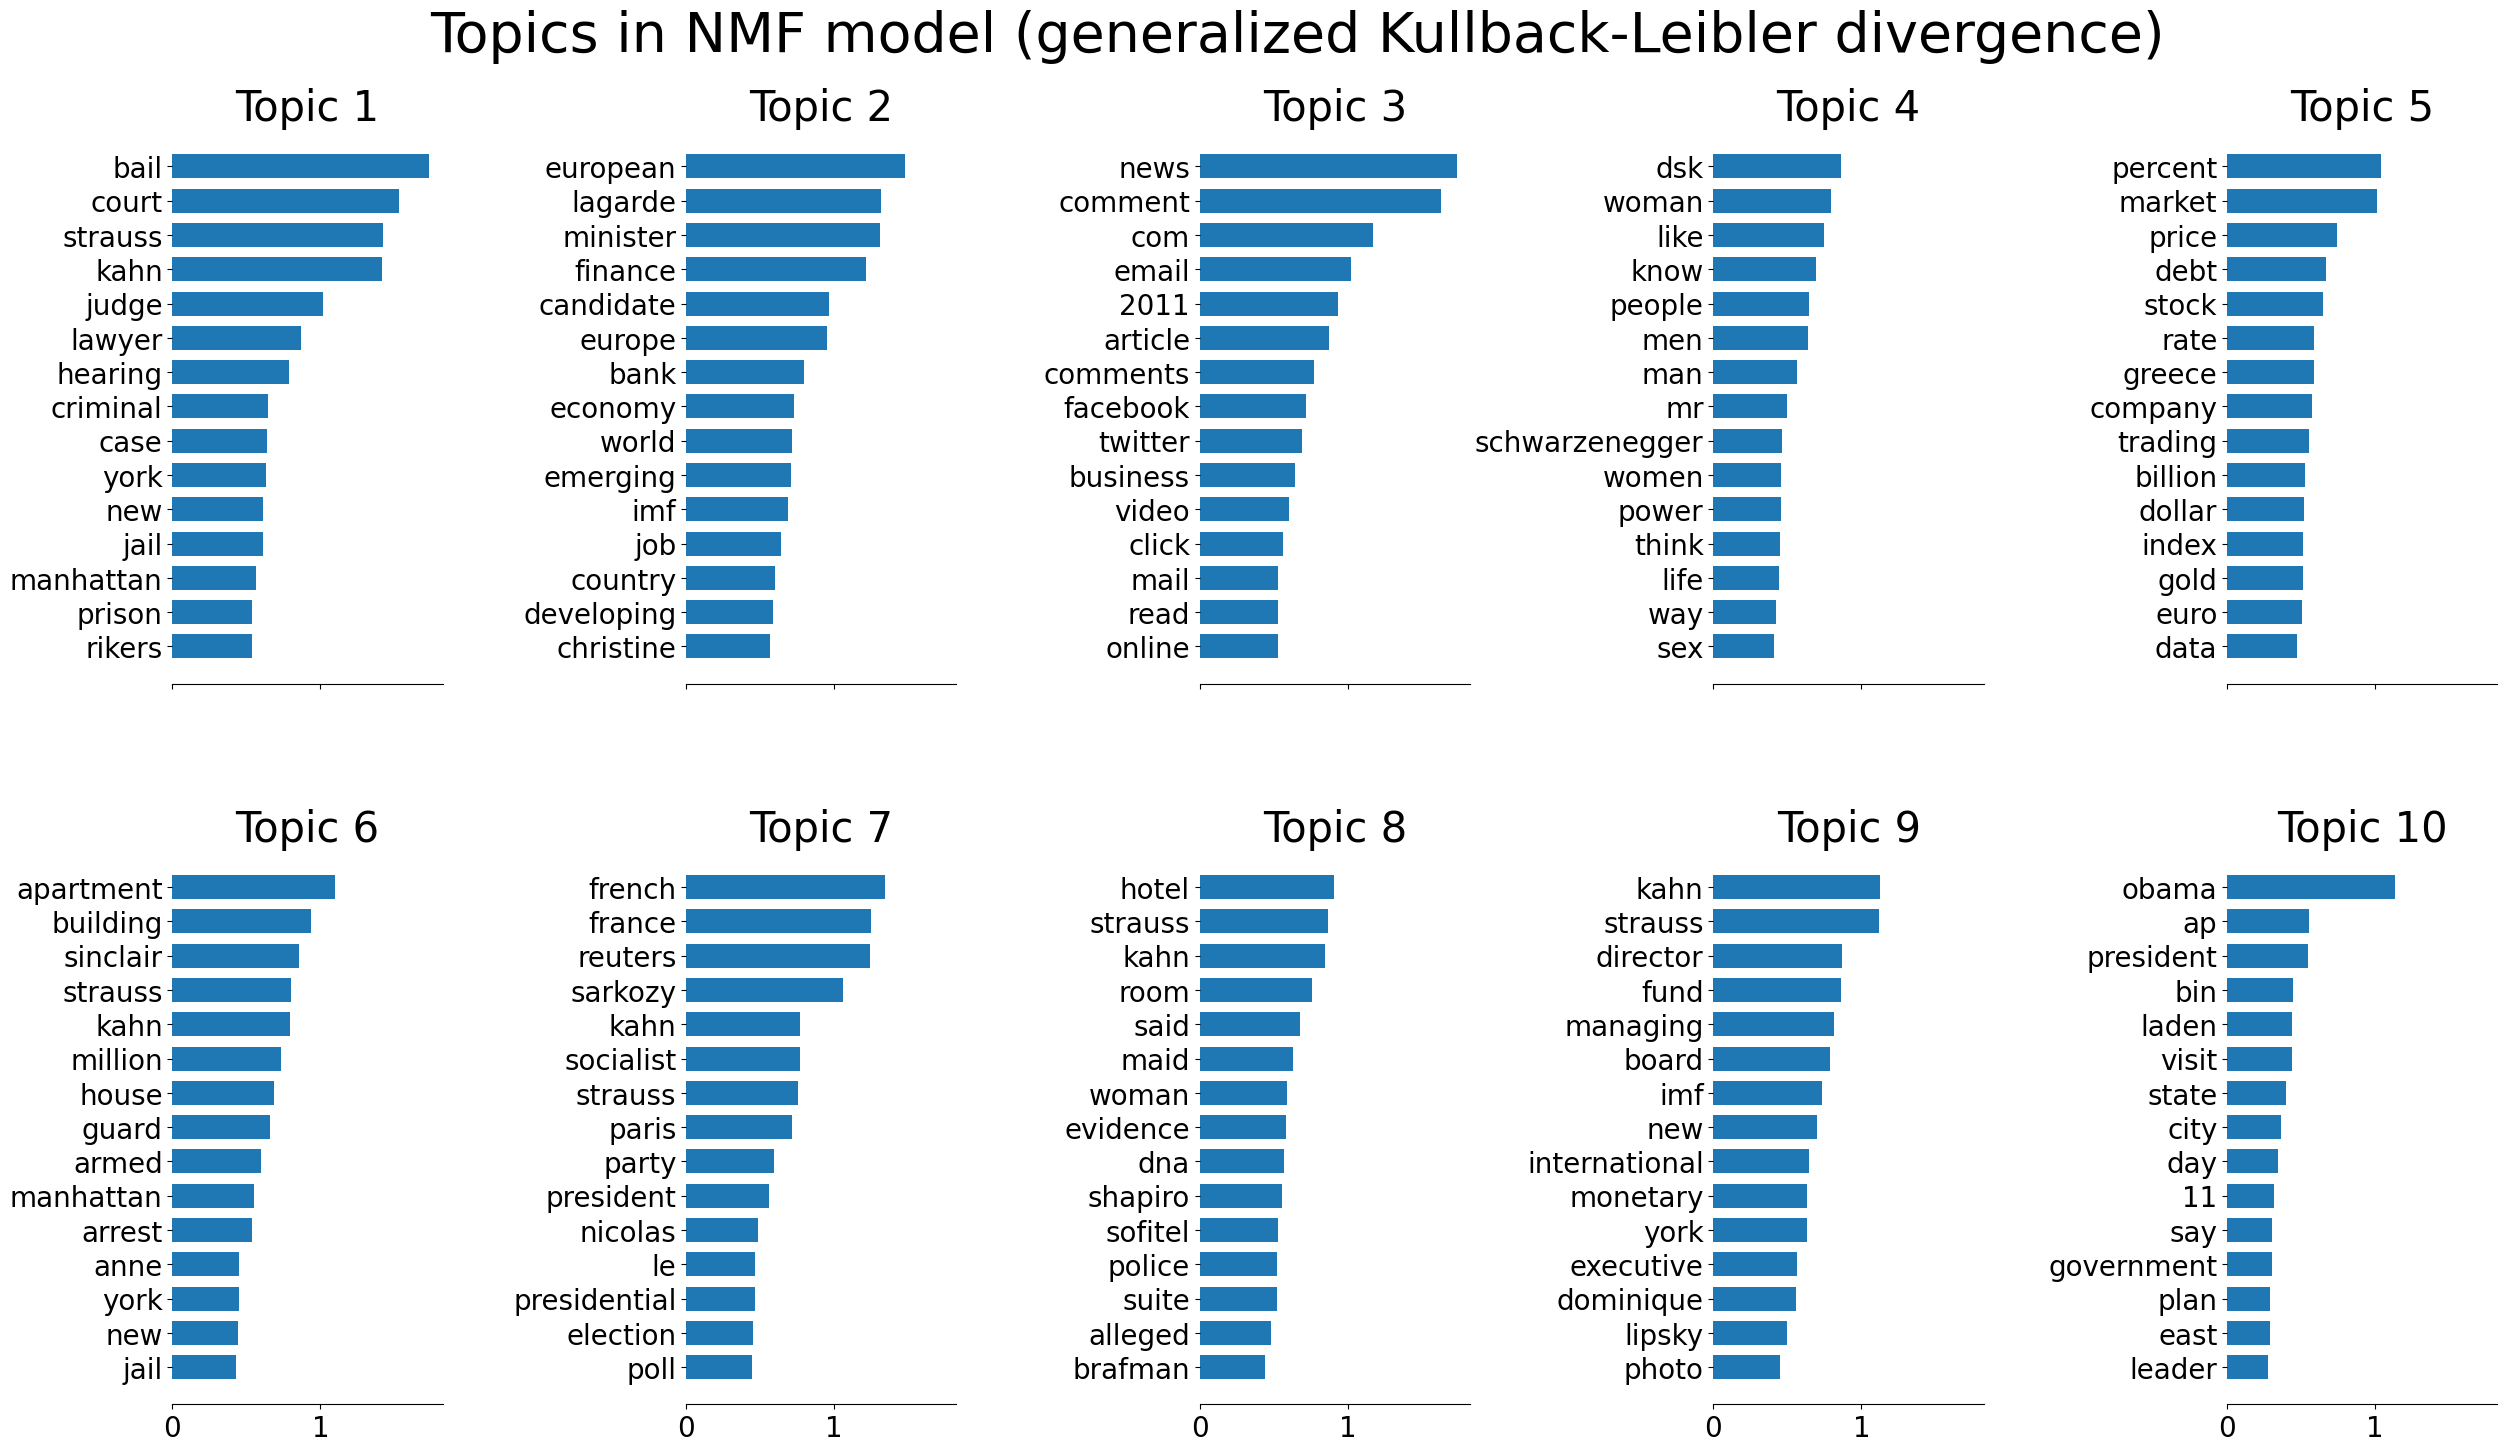

In [17]:
# Fit the NMF model
print(
    "\n" * 2,
    "Fitting the NMF model (generalized Kullback-Leibler "
    "divergence) with tf-idf features, n_samples=%d and n_features=%d..."
    % (n_samples, n_features),
)
nmf = NMF(
    n_components=n_components,
    random_state=1,
    init=init,
    beta_loss="kullback-leibler",
    solver="mu",
    max_iter=1000,
    alpha_W=0.00005,
    alpha_H=0.00005,
    l1_ratio=0.5,
).fit(tfidf)
tfidf_feature_names = tfidf_vectorizer.get_feature_names_out()
plot_top_words(
    nmf,
    tfidf_feature_names,
    n_top_words,
    "Topics in NMF model (generalized Kullback-Leibler divergence)",
)

In [18]:
# # Visualize the topics
# pyLDAvis.enable_notebook()

# LDAvis_prepared = pyLDAvis.gensim_models.prepare(lda, corpus, id2word)

# LDAvis_prepared